## Análisis de Series Temporales (Estacionalidad, Tendencia, Estacionariedad)
A continuación, cargaremos los datos limpios y crearemos una fecha a partir de `Anio` y `SemanaEstadistica`. Luego, analizaremos la serie temporal de `NumTotal`.

In [4]:
%pip install pandas numpy matplotlib statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


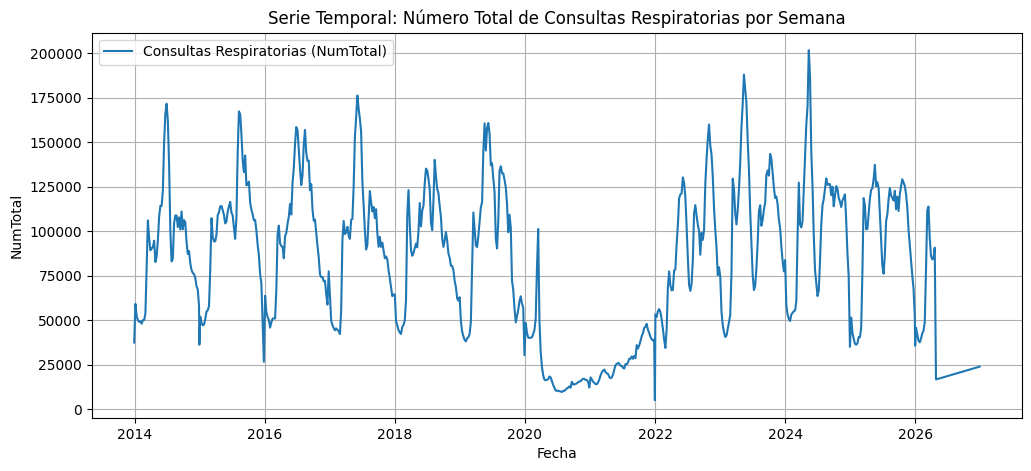

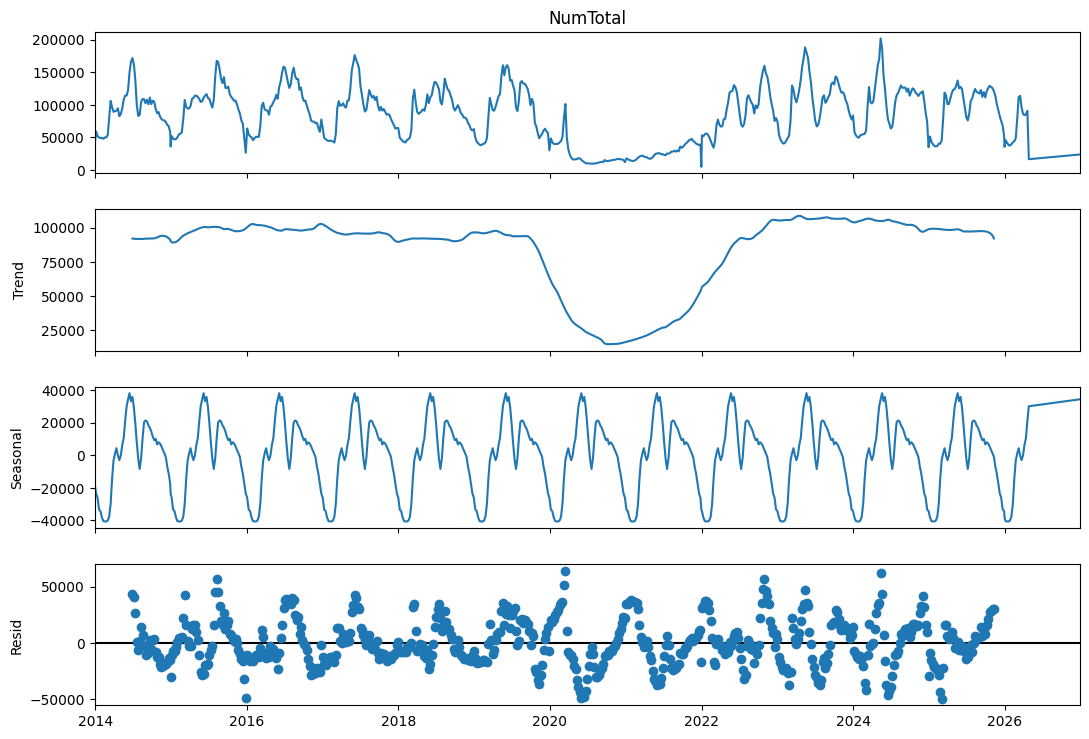

--- Prueba ADF (Augmented Dickey-Fuller) ---
Estadístico ADF: -5.090653270856082
p-value: 1.4638532317080305e-05
Valores Críticos:
   1%: -3.4405132737812596
   5%: -2.8660244429195725
   10%: -2.5691581552588447

Conclusión: Rechazamos la hipótesis nula. La serie es ESTACIONARIA.


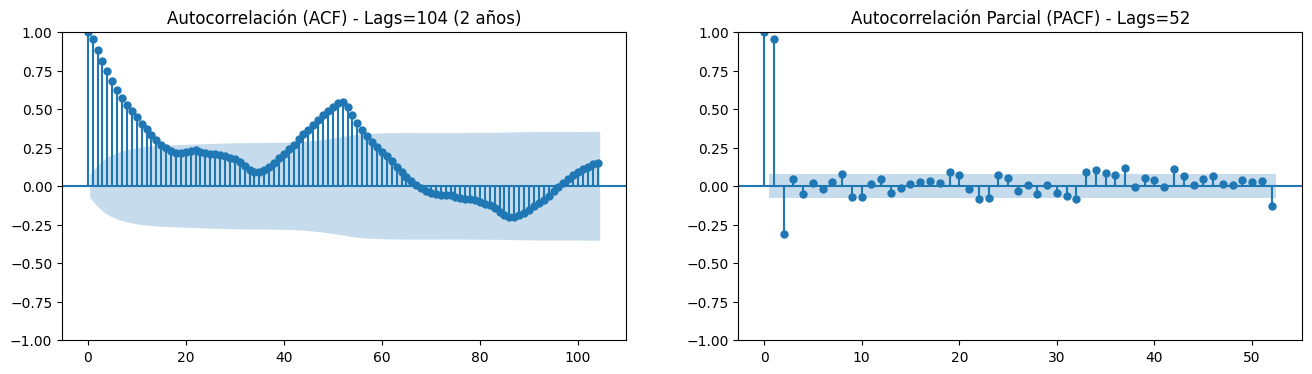

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from datetime import datetime

# 1. Cargar el dataset limpio
df = pd.read_parquet('dataset_limpios/at_urg_respiratorio_limpio.parquet')

# 2. Crear una columna de fecha a partir de Anio y SemanaEstadistica
# Usamos el lunes de cada semana como representación de la fecha
def get_date_from_iso_week(year, week):
    # Formato '%G-W%V-%u' -> %G año ISO, %V semana ISO, %u día de la semana (1-7)
    date_str = f'{year}-W{week:02d}-1' 
    try:
        return datetime.strptime(date_str, '%G-W%V-%u')
    except ValueError:
        # Algunos años pueden tener 53 semanas, si hay error usamos el ultimo dia del año
        return datetime(year, 12, 31)

df['Fecha'] = df.apply(lambda row: get_date_from_iso_week(int(row['Anio']), int(row['SemanaEstadistica'])), axis=1)

# Agrupar por fecha y sumar el NumTotal
ts_df = df.groupby('Fecha')['NumTotal'].sum().reset_index()
ts_df.set_index('Fecha', inplace=True)
ts_df.sort_index(inplace=True)

# 3. Visualización de la Serie Temporal
plt.figure(figsize=(12, 5))
plt.plot(ts_df.index, ts_df['NumTotal'], label='Consultas Respiratorias (NumTotal)')
plt.title('Serie Temporal: Número Total de Consultas Respiratorias por Semana')
plt.xlabel('Fecha')
plt.ylabel('NumTotal')
plt.legend()
plt.grid(True)
plt.show()

# 4. Descomposición de la serie (Tendencia, Estacionalidad, Ruido)
# Asumimos una estacionalidad anual. Al tener datos semanales, el periodo es 52
decomposition = seasonal_decompose(ts_df['NumTotal'], model='additive', period=52)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

# 5. Prueba de Estacionariedad (Test de Dickey-Fuller Aumentado - ADF)
def adf_test(series):
    result = adfuller(series.dropna())
    print('--- Prueba ADF (Augmented Dickey-Fuller) ---')
    print('Estadístico ADF:', result[0])
    print('p-value:', result[1])
    print('Valores Críticos:')
    for key, value in result[4].items():
        print(f'   {key}: {value}')
    if result[1] <= 0.05:
        print("\nConclusión: Rechazamos la hipótesis nula. La serie es ESTACIONARIA.")
    else:
        print("\nConclusión: No podemos rechazar la hipótesis nula. La serie NO ES ESTACIONARIA.")

adf_test(ts_df['NumTotal'])

# 6. Gráficos ACF y PACF para determinar parámetros pdq de modelos ARIMA/SARIMA
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(ts_df['NumTotal'].dropna(), ax=axes[0], lags=104, title='Autocorrelación (ACF) - Lags=104 (2 años)')
plot_pacf(ts_df['NumTotal'].dropna(), ax=axes[1], lags=52, title='Autocorrelación Parcial (PACF) - Lags=52')
plt.show()
